# 三方案市场参与对比实验

本 notebook 对三个方案进行统一对比：

- **方案一**：仅参与电量市场，不参与容量/调频市场。
- **方案二**：参与电量市场和容量市场，但不进行日内优化；这里直接采用 `max_profit_1` 的结果。
- **方案三**：本文提出的完整方案，同时参与电量市场和容量市场，并进行日内优化/滚动修正。

本 notebook 会统一输出三种方案的收益分解、时段投标及对比图。

In [31]:
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from __future__ import annotations

import importlib
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(p for p in [cwd, *cwd.parents] if (p / 'myexp').exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import myexp.heterogeneous_ev_bid_analysis as heterogeneous_ev_bid_analysis
import myexp.energy_only_market_comparison as energy_only_market_comparison
from myexp.max_profit_1 import max_profit_1

heterogeneous_ev_bid_analysis = importlib.reload(heterogeneous_ev_bid_analysis)
energy_only_market_comparison = importlib.reload(energy_only_market_comparison)
_build_context = heterogeneous_ev_bid_analysis._build_context
_run_experiment = heterogeneous_ev_bid_analysis._run_experiment
_solve_energy_only = energy_only_market_comparison._solve_energy_only
_recompute_full_market_metrics = energy_only_market_comparison._recompute_full_market_metrics

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True)
print('project_root =', project_root)
print('results_dir =', results_dir)

project_root = E:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main
results_dir = E:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\results


In [32]:
EV_COUNT = 120
AGGREGATE_EVS = False
DAY_PRICE = 15

print('EV_COUNT =', EV_COUNT)
print('AGGREGATE_EVS =', AGGREGATE_EVS)
print('DAY_PRICE =', DAY_PRICE)
print('DAY_REG =', DAY_PRICE + 1)

EV_COUNT = 120
AGGREGATE_EVS = False
DAY_PRICE = 15
DAY_REG = 16


In [33]:
def run_scheme_1_energy_only(ev_count: int = 120, aggregate_evs: bool = False, day_price: int = 15) -> dict:
    ctx, _ = _build_context(ev_count=ev_count, aggregate_evs=aggregate_evs, day_price=day_price)
    energy_only = _solve_energy_only(ctx)
    nofslots = int(ctx['NOFSLOTS'])
    return {
        'name': '方案一：仅电量市场',
        'slot': np.arange(1, nofslots + 1, dtype=int),
        'bid_p_mw': np.asarray(energy_only['bid_p_mw'], dtype=float),
        'bid_r_mw': np.zeros(nofslots, dtype=float),
        'energy_revenue_usd': np.asarray(energy_only['energy_fee_usd'], dtype=float),
        'capacity_revenue_usd': np.zeros(nofslots, dtype=float),
        'mileage_revenue_usd': np.zeros(nofslots, dtype=float),
        'battery_deg_usd': np.asarray(energy_only['battery_deg_usd'], dtype=float),
        'profit_usd': np.asarray(energy_only['profit_usd'], dtype=float),
        'total_profit_usd': float(energy_only['total_profit_usd']),
        'total_energy_revenue_usd': float(energy_only['total_energy_fee_usd']),
        'total_capacity_revenue_usd': 0.0,
        'total_mileage_revenue_usd': 0.0,
        'total_battery_deg_usd': float(energy_only['total_battery_deg_usd']),
    }


def run_scheme_2_max_profit_1(ev_count: int = 120, aggregate_evs: bool = False, day_price: int = 15) -> dict:
    ctx, _ = _build_context(ev_count=ev_count, aggregate_evs=aggregate_evs, day_price=day_price)
    max_profit_1(ctx)

    param = ctx['param']
    result = ctx['result']
    delta_t = float(ctx['delta_t'])
    nofslots = int(ctx['NOFSLOTS'])

    bid_p = np.asarray(result['Bid_P_init'], dtype=float)
    bid_r = np.asarray(result['Bid_R_init'], dtype=float)
    reg_energy_coeff = (np.asarray(param.hourly_Distribution) @ np.asarray(param.d_s)) * np.asarray(param.price_e)

    energy_revenue = (np.asarray(param.price_e) * bid_p + reg_energy_coeff * bid_r) * delta_t
    capacity_revenue = np.asarray(param.price_reg[:, 0]) * bid_r * float(param.s_perf) * delta_t
    mileage_revenue = np.asarray(param.price_reg[:, 1]) * np.asarray(param.hourly_Mileage) * bid_r * float(param.s_perf) * delta_t
    battery_deg = np.asarray(result.get('BatteryDeg_day', np.zeros(nofslots)), dtype=float)
    profit = energy_revenue + capacity_revenue + mileage_revenue - battery_deg

    return {
        'name': '方案二：max_profit_1',
        'slot': np.arange(1, nofslots + 1, dtype=int),
        'bid_p_mw': bid_p,
        'bid_r_mw': bid_r,
        'energy_revenue_usd': energy_revenue,
        'capacity_revenue_usd': capacity_revenue,
        'mileage_revenue_usd': mileage_revenue,
        'battery_deg_usd': battery_deg,
        'profit_usd': profit,
        'total_profit_usd': float(np.sum(profit)),
        'total_energy_revenue_usd': float(np.sum(energy_revenue)),
        'total_capacity_revenue_usd': float(np.sum(capacity_revenue)),
        'total_mileage_revenue_usd': float(np.sum(mileage_revenue)),
        'total_battery_deg_usd': float(np.sum(battery_deg)),
    }


def run_scheme_3_full_market(ev_count: int = 120, aggregate_evs: bool = False, day_price: int = 15) -> dict:
    ctx, _ = _run_experiment(ev_count=ev_count, aggregate_evs=aggregate_evs, day_price=day_price)
    full_market = _recompute_full_market_metrics(ctx)
    nofslots = int(ctx['NOFSLOTS'])
    return {
        'name': '方案三：完整方案',
        'slot': np.arange(1, nofslots + 1, dtype=int),
        'bid_p_mw': np.asarray(full_market['bid_p_mw'], dtype=float),
        'bid_r_mw': np.asarray(full_market['bid_r_mw'], dtype=float),
        'energy_revenue_usd': np.asarray(full_market['energy_fee_usd'], dtype=float),
        'capacity_revenue_usd': np.asarray(full_market['reg_capacity_usd'], dtype=float),
        'mileage_revenue_usd': np.asarray(full_market['reg_mileage_usd'], dtype=float),
        'battery_deg_usd': np.asarray(full_market['battery_deg_usd'], dtype=float),
        'profit_usd': np.asarray(full_market['profit_usd'], dtype=float),
        'total_profit_usd': float(full_market['total_profit_usd']),
        'total_energy_revenue_usd': float(full_market['total_energy_fee_usd']),
        'total_capacity_revenue_usd': float(full_market['total_reg_capacity_usd']),
        'total_mileage_revenue_usd': float(full_market['total_reg_mileage_usd']),
        'total_battery_deg_usd': float(full_market['total_battery_deg_usd']),
    }

In [34]:
scheme_1 = run_scheme_1_energy_only(ev_count=EV_COUNT, aggregate_evs=AGGREGATE_EVS, day_price=DAY_PRICE)
scheme_2 = run_scheme_2_max_profit_1(ev_count=EV_COUNT, aggregate_evs=AGGREGATE_EVS, day_price=DAY_PRICE)
scheme_3 = run_scheme_3_full_market(ev_count=EV_COUNT, aggregate_evs=AGGREGATE_EVS, day_price=DAY_PRICE)

schemes = [scheme_1, scheme_2, scheme_3]
print('三种方案运行完成。')

  信号数据 shape: (43200, 31)
  信号范围: [-1.0000, 1.0000]
  场景数 (NOFSCEN): 22
  d_s values: [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3
  0.4  0.5  0.6  0.7  0.8  0.9  1.   1. ]
    信号[0]=-0.2042 -> s_idx=9
    信号[1]=-0.2372 -> s_idx=9
    信号[2]=-0.2696 -> s_idx=9
    信号[3]=-0.2936 -> s_idx=9
    信号[4]=-0.3150 -> s_idx=8
    第1天（day_idx=2）分布: sum=1800, 归一化后sum=1.000000
    第2天（day_idx=3）分布: sum=1800, 归一化后sum=1.000000
    第3天（day_idx=4）分布: sum=1800, 归一化后sum=1.000000
    第4天（day_idx=5）分布: sum=1800, 归一化后sum=1.000000
    第5天（day_idx=6）分布: sum=1800, 归一化后sum=1.000000
    第6天（day_idx=7）分布: sum=1800, 归一化后sum=1.000000
    第7天（day_idx=8）分布: sum=1800, 归一化后sum=1.000000
    第8天（day_idx=9）分布: sum=1800, 归一化后sum=1.000000
    第9天（day_idx=10）分布: sum=1800, 归一化后sum=1.000000
    第10天（day_idx=11）分布: sum=1800, 归一化后sum=1.000000
    第11天（day_idx=12）分布: sum=1800, 归一化后sum=1.000000
    第12天（day_idx=13）分布: sum=1800, 归一化后sum=1.000000
    第13天（day_idx=14）分布: sum=1800, 归一化后sum=1.000000
    第14天（d

e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\atoms\affine\reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


slot 1: bidding ok
  信号数据 shape: (43200, 31)
  信号范围: [-1.0000, 1.0000]
  场景数 (NOFSCEN): 22
  d_s values: [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3
  0.4  0.5  0.6  0.7  0.8  0.9  1.   1. ]
    信号[0]=-0.2042 -> s_idx=9
    信号[1]=-0.2372 -> s_idx=9
    信号[2]=-0.2696 -> s_idx=9
    信号[3]=-0.2936 -> s_idx=9
    信号[4]=-0.3150 -> s_idx=8
    第1天（day_idx=2）分布: sum=1800, 归一化后sum=1.000000
    第2天（day_idx=3）分布: sum=1800, 归一化后sum=1.000000
    第3天（day_idx=4）分布: sum=1800, 归一化后sum=1.000000
    第4天（day_idx=5）分布: sum=1800, 归一化后sum=1.000000
    第5天（day_idx=6）分布: sum=1800, 归一化后sum=1.000000
    第6天（day_idx=7）分布: sum=1800, 归一化后sum=1.000000
    第7天（day_idx=8）分布: sum=1800, 归一化后sum=1.000000
    第8天（day_idx=9）分布: sum=1800, 归一化后sum=1.000000
    第9天（day_idx=10）分布: sum=1800, 归一化后sum=1.000000
    第10天（day_idx=11）分布: sum=1800, 归一化后sum=1.000000
    第11天（day_idx=12）分布: sum=1800, 归一化后sum=1.000000
    第12天（day_idx=13）分布: sum=1800, 归一化后sum=1.000000
    第13天（day_idx=14）分布: sum=1800, 归一化后sum=

e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\atoms\affine\reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


slot 1: bidding ok
slot 1: rolling bid ok at t_cap 1
slot 1: rolling bid ok at t_cap 1201
slot 2: rolling bid ok at t_cap 2401
slot 3: rolling bid ok at t_cap 3601
slot 3: rolling bid ok at t_cap 4801
slot 4: rolling bid ok at t_cap 6001
slot 5: rolling bid ok at t_cap 7201
slot 5: rolling bid ok at t_cap 8401
slot 6: rolling bid ok at t_cap 9601
slot 7: rolling bid ok at t_cap 10801
slot 7: rolling bid ok at t_cap 12001
slot 8: rolling bid ok at t_cap 13201
slot 9: rolling bid ok at t_cap 14401
slot 9: rolling bid ok at t_cap 15601
slot 10: rolling bid ok at t_cap 16801
slot 11: rolling bid ok at t_cap 18001
slot 11: rolling bid ok at t_cap 19201
slot 12: rolling bid ok at t_cap 20401
slot 13: rolling bid ok at t_cap 21601
slot 13: rolling bid ok at t_cap 22801
slot 14: rolling bid ok at t_cap 24001
slot 15: rolling bid ok at t_cap 25201
slot 15: rolling bid ok at t_cap 26401
slot 16: rolling bid ok at t_cap 27601
slot 17: rolling bid ok at t_cap 28801
slot 17: rolling bid ok at t_cap

In [35]:
summary_df = pd.DataFrame([
    {
        '方案': s['name'],
        '总净收益(USD)': s['total_profit_usd'],
        '能量收益(USD)': s['total_energy_revenue_usd'],
        '容量收益(USD)': s['total_capacity_revenue_usd'],
        '里程收益(USD)': s['total_mileage_revenue_usd'],
        '电池退化费用(USD)': s['total_battery_deg_usd'],
    }
    for s in schemes
])
summary_df

,方案,总净收益(USD),能量收益(USD),容量收益(USD),里程收益(USD),电池退化费用(USD)
0,方案一：仅电量市场,1027.987331,1027.987331,0.000000,0.000000,0.000000
1,方案二：max_profit_1,2733.791778,465.316720,1793.861001,1537.847915,1063.233857
2,方案三：完整方案,2958.137045,385.544731,1838.360697,1662.470404,928.238787


## 结果解读建议

- 方案一可以看作不进入容量/调频市场时，仅靠电量套利获得的基线收益。
- 方案二反映了**只做日前联合优化**时的理论收益水平。
- 方案三反映了在实际滚动修正和实时执行下的完整收益表现。
- 若方案三显著优于方案一，则说明参与容量/调频市场有价值；若方案三接近或优于方案二，则说明日内优化机制有效。

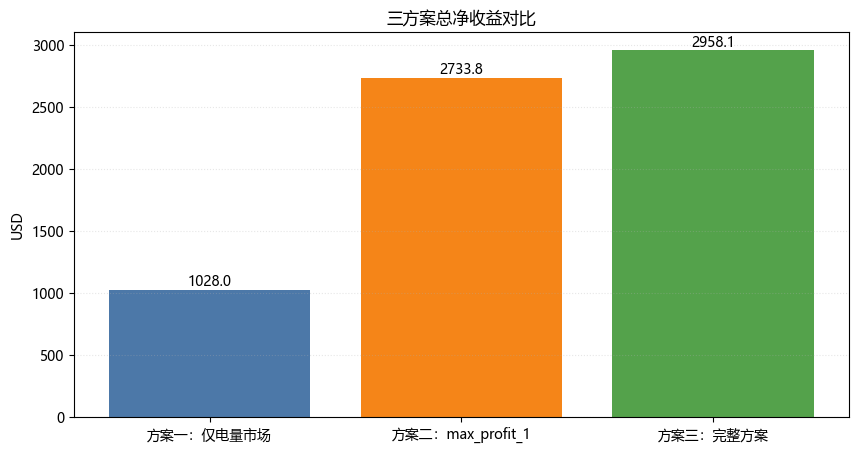

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(summary_df['方案'], summary_df['总净收益(USD)'], color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_title('三方案总净收益对比')
ax.set_ylabel('USD')
ax.grid(axis='y', linestyle=':', alpha=0.3)
for i, v in enumerate(summary_df['总净收益(USD)']):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=0)
plt.show()

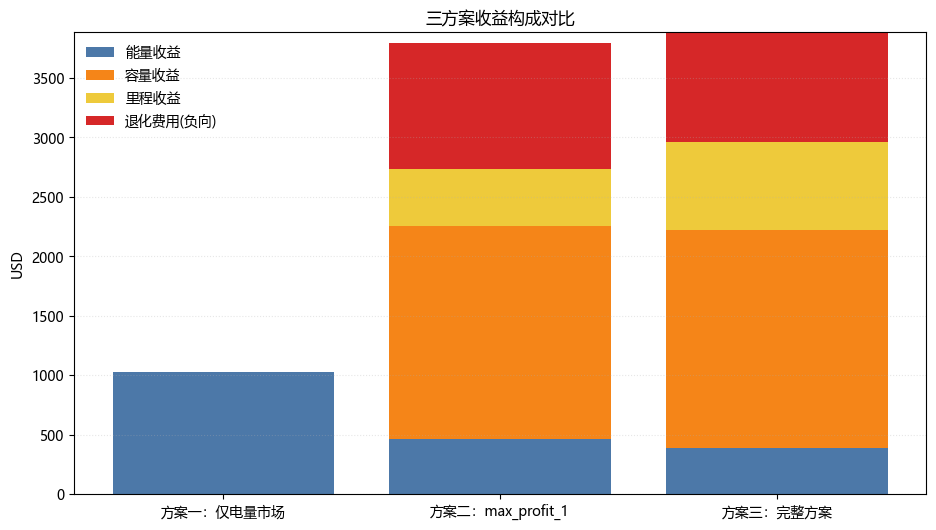

In [37]:
composition_df = summary_df.copy()
composition_df['负退化费用(USD)'] = -composition_df['电池退化费用(USD)']

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(composition_df['方案'], composition_df['能量收益(USD)'], label='能量收益', color='#4c78a8')
ax.bar(composition_df['方案'], composition_df['容量收益(USD)'], bottom=composition_df['能量收益(USD)'], label='容量收益', color='#f58518')
ax.bar(
    composition_df['方案'],
    composition_df['里程收益(USD)'],
    bottom=composition_df['能量收益(USD)'] + composition_df['容量收益(USD)'],
    label='里程收益',
    color='#eeca3b',
)
ax.bar(
    composition_df['方案'],
    composition_df['负退化费用(USD)'],
    bottom=composition_df['能量收益(USD)'] + composition_df['容量收益(USD)'] + composition_df['里程收益(USD)'],
    label='退化费用(负向)',
    color='#d62728',
)
ax.set_title('三方案收益构成对比')
ax.set_ylabel('USD')
ax.grid(axis='y', linestyle=':', alpha=0.3)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.show()


In [38]:
slot_df = pd.DataFrame({'slot': scheme_1['slot']})
for idx, s in enumerate(schemes, start=1):
    slot_df[f'scheme_{idx}_bid_p_mw'] = s['bid_p_mw']
    slot_df[f'scheme_{idx}_bid_r_mw'] = s['bid_r_mw']
    slot_df[f'scheme_{idx}_profit_usd'] = s['profit_usd']
slot_df.head()

,slot,scheme_1_bid_p_mw,scheme_1_bid_r_mw,scheme_1_profit_usd,scheme_2_bid_p_mw,scheme_2_bid_r_mw,scheme_2_profit_usd,scheme_3_bid_p_mw,scheme_3_bid_r_mw,scheme_3_profit_usd
0,1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.0,0.0,0.0,-0.333333,0.666667,-19.049256,-0.333333,0.666667,-20.626390
2,3,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,0.0,0.0,0.0,-0.285714,0.714286,-4.844944,-0.285714,0.714286,1.552818
4,5,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


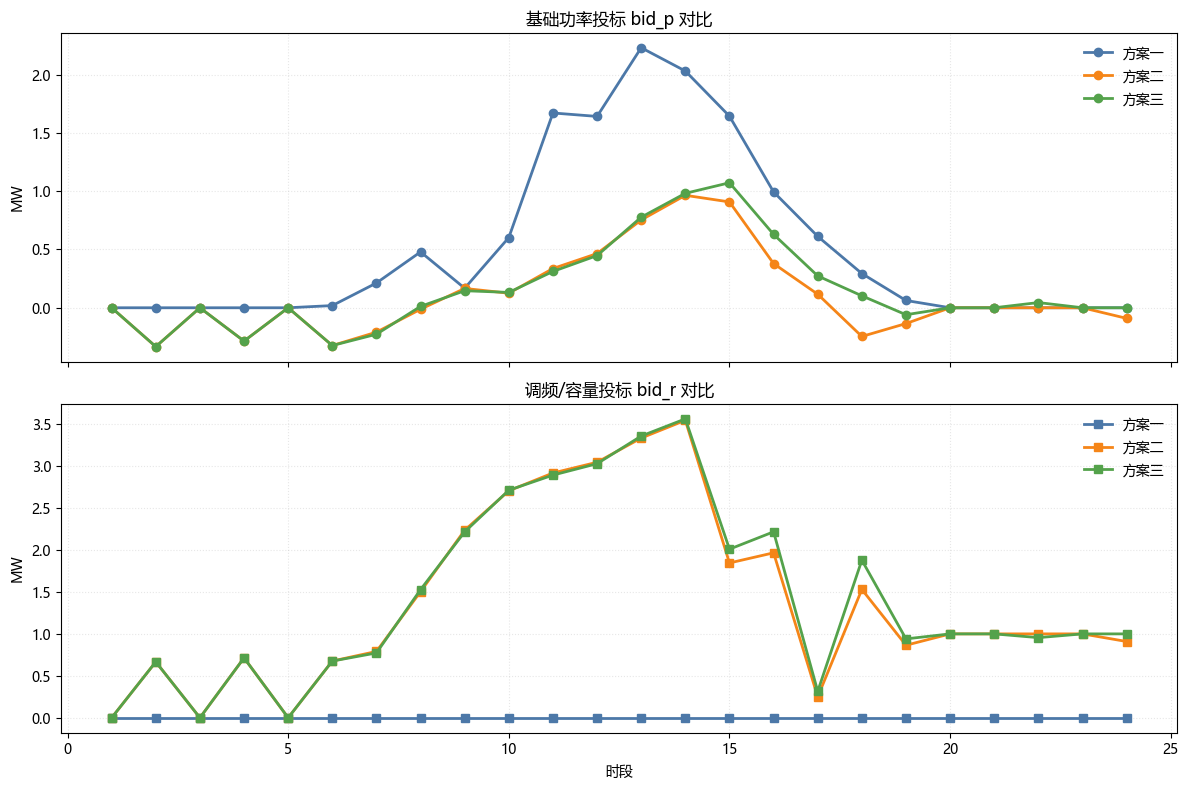

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
labels = ['方案一', '方案二', '方案三']
colors = ['#4c78a8', '#f58518', '#54a24b']

for label, color, scheme in zip(labels, colors, schemes):
    axes[0].plot(scheme['slot'], scheme['bid_p_mw'], marker='o', linewidth=2, label=label, color=color)
    axes[1].plot(scheme['slot'], scheme['bid_r_mw'], marker='s', linewidth=2, label=label, color=color)

axes[0].set_title('基础功率投标 bid_p 对比')
axes[0].set_ylabel('MW')
axes[0].grid(linestyle=':', alpha=0.3)
axes[0].legend(frameon=False)

axes[1].set_title('调频/容量投标 bid_r 对比')
axes[1].set_xlabel('时段')
axes[1].set_ylabel('MW')
axes[1].grid(linestyle=':', alpha=0.3)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

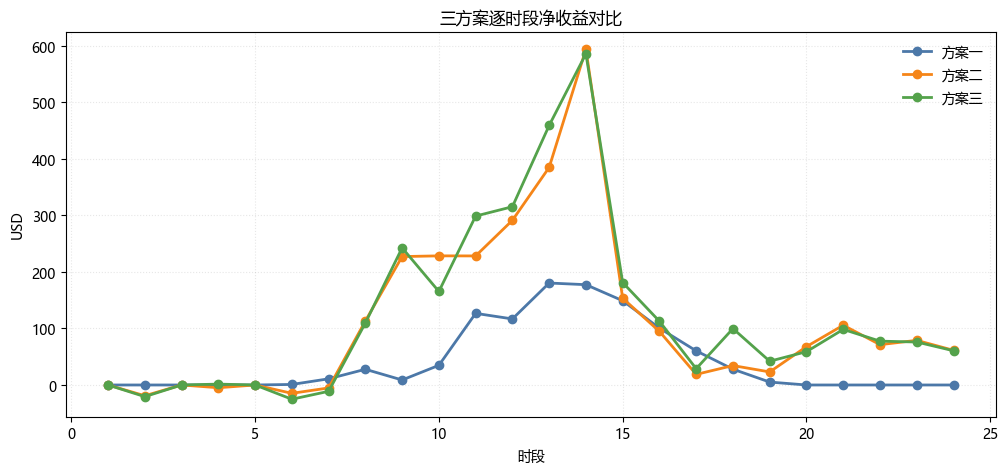

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, color, scheme in zip(labels, colors, schemes):
    ax.plot(scheme['slot'], scheme['profit_usd'], marker='o', linewidth=2, label=label, color=color)
ax.set_title('三方案逐时段净收益对比')
ax.set_xlabel('时段')
ax.set_ylabel('USD')
ax.grid(linestyle=':', alpha=0.3)
ax.legend(frameon=False)
plt.show()